In [266]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [267]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath(".."))

from src.optimization import *
from src.oracles import *
from src.plot_trajectory_2d import *

# Эксперимент 3.2

## Квадратичные функции

### Задаем матрицы

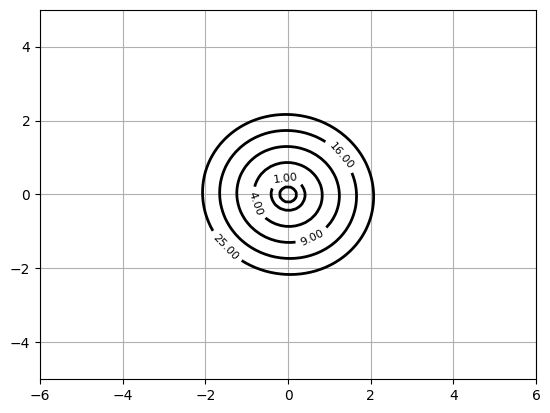

In [268]:
A = np.array(
    [[11.67, 0.29],
    [0.29, 10.67]]
)
b = np.zeros(2)

square_oracle_1 = QuadraticOracle(A, b)
plot_levels(square_oracle_1.func)

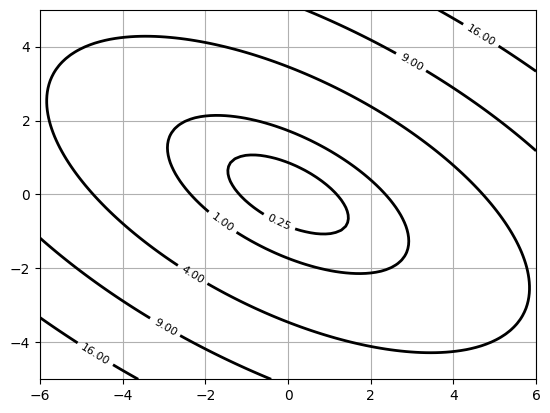

In [269]:
A = np.array(
    [[0.36, 0.29],
    [0.29, 0.67]]
)
b = np.zeros(2)

square_oracle_2 = QuadraticOracle(A, b)
plot_levels(square_oracle_2.func)

### Запускаем методы

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


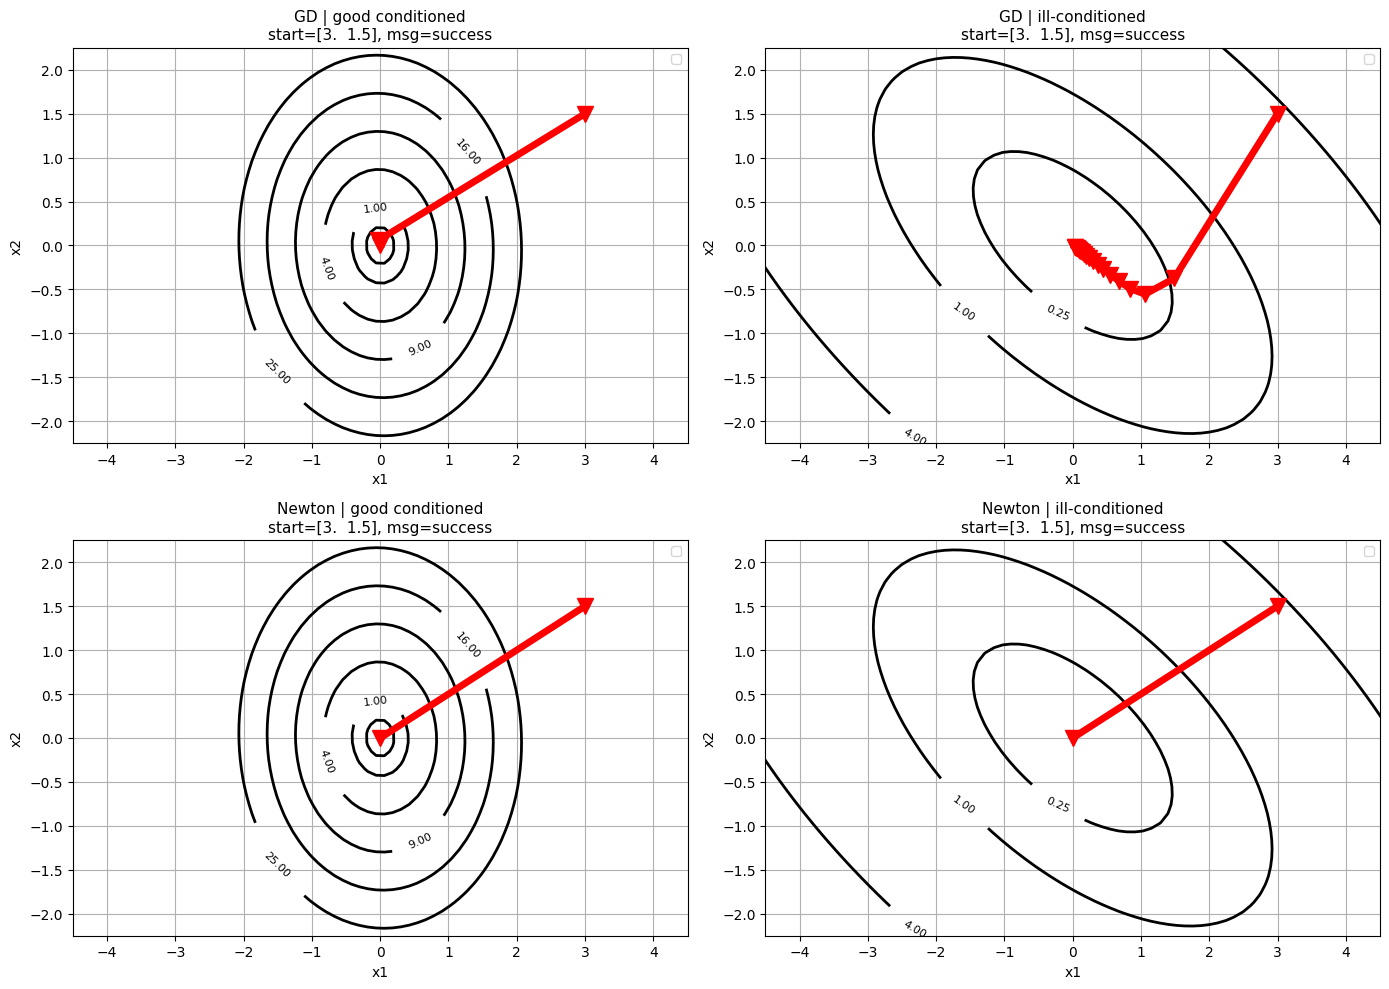

In [270]:
import matplotlib.pyplot as plt

start_point = np.array([3.0, 1.5])

cases = [
    ("ГС, хорошая обусловленность", gradient_descent, square_oracle_1),
    ("ГС, плохая обусловленность", gradient_descent, square_oracle_2),
    ("Ньютон, хорошая обусловленность", newton, square_oracle_1),
    ("Ньютон, плохая обусловленность", newton, square_oracle_2),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (title, method, oracle) in zip(axes, cases):
    plt.sca(ax)

    x_star, msg, history = method(oracle, start_point, trace=True)

    plot_levels(oracle.func)
    plot_trajectory(oracle.func, list(history['x']), fit_axis=True)

    ax.set_title(f"{title}\nстарт={start_point}, статус={msg}", fontsize=11)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()


## Функция Билла

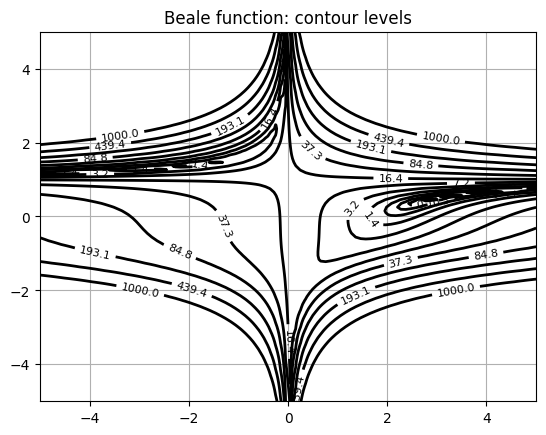

In [271]:
oracle = NonConvexOracle()
plot_levels(oracle.func, xrange=[-5, 5], yrange=[-5, 5], levels=np.geomspace(1e-2, 1e3, 15))
plt.title("Функция Била: линии уровня")
plt.show()


In [272]:
oracle.grad((3, 0.5)), oracle.grad((0, 1)), oracle.grad((0.1005379373, -2.6445135850))

(array([-0.,  0.]), array([0., 0.]), array([-2.28051604e-08,  2.35523911e-09]))

### Траектории градиентного спуска и Ньютона

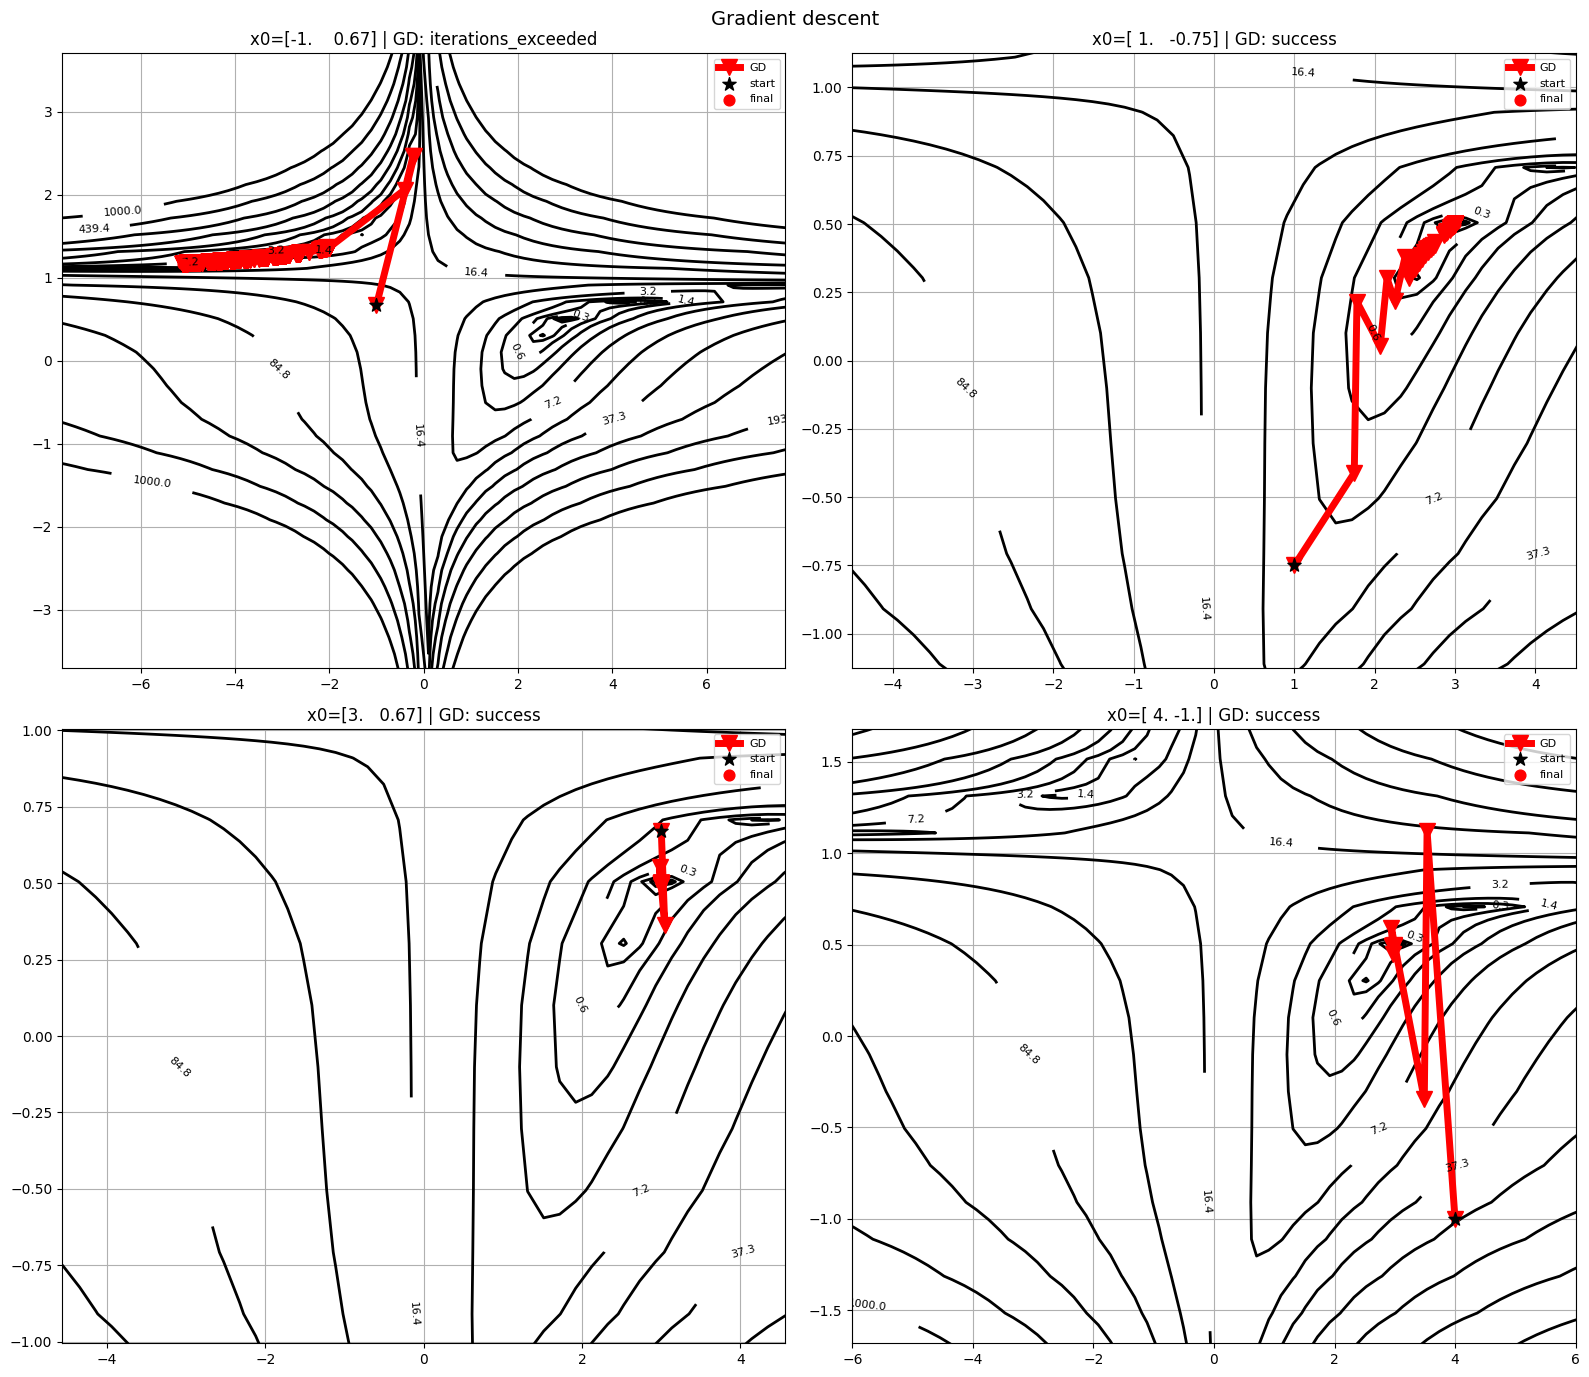

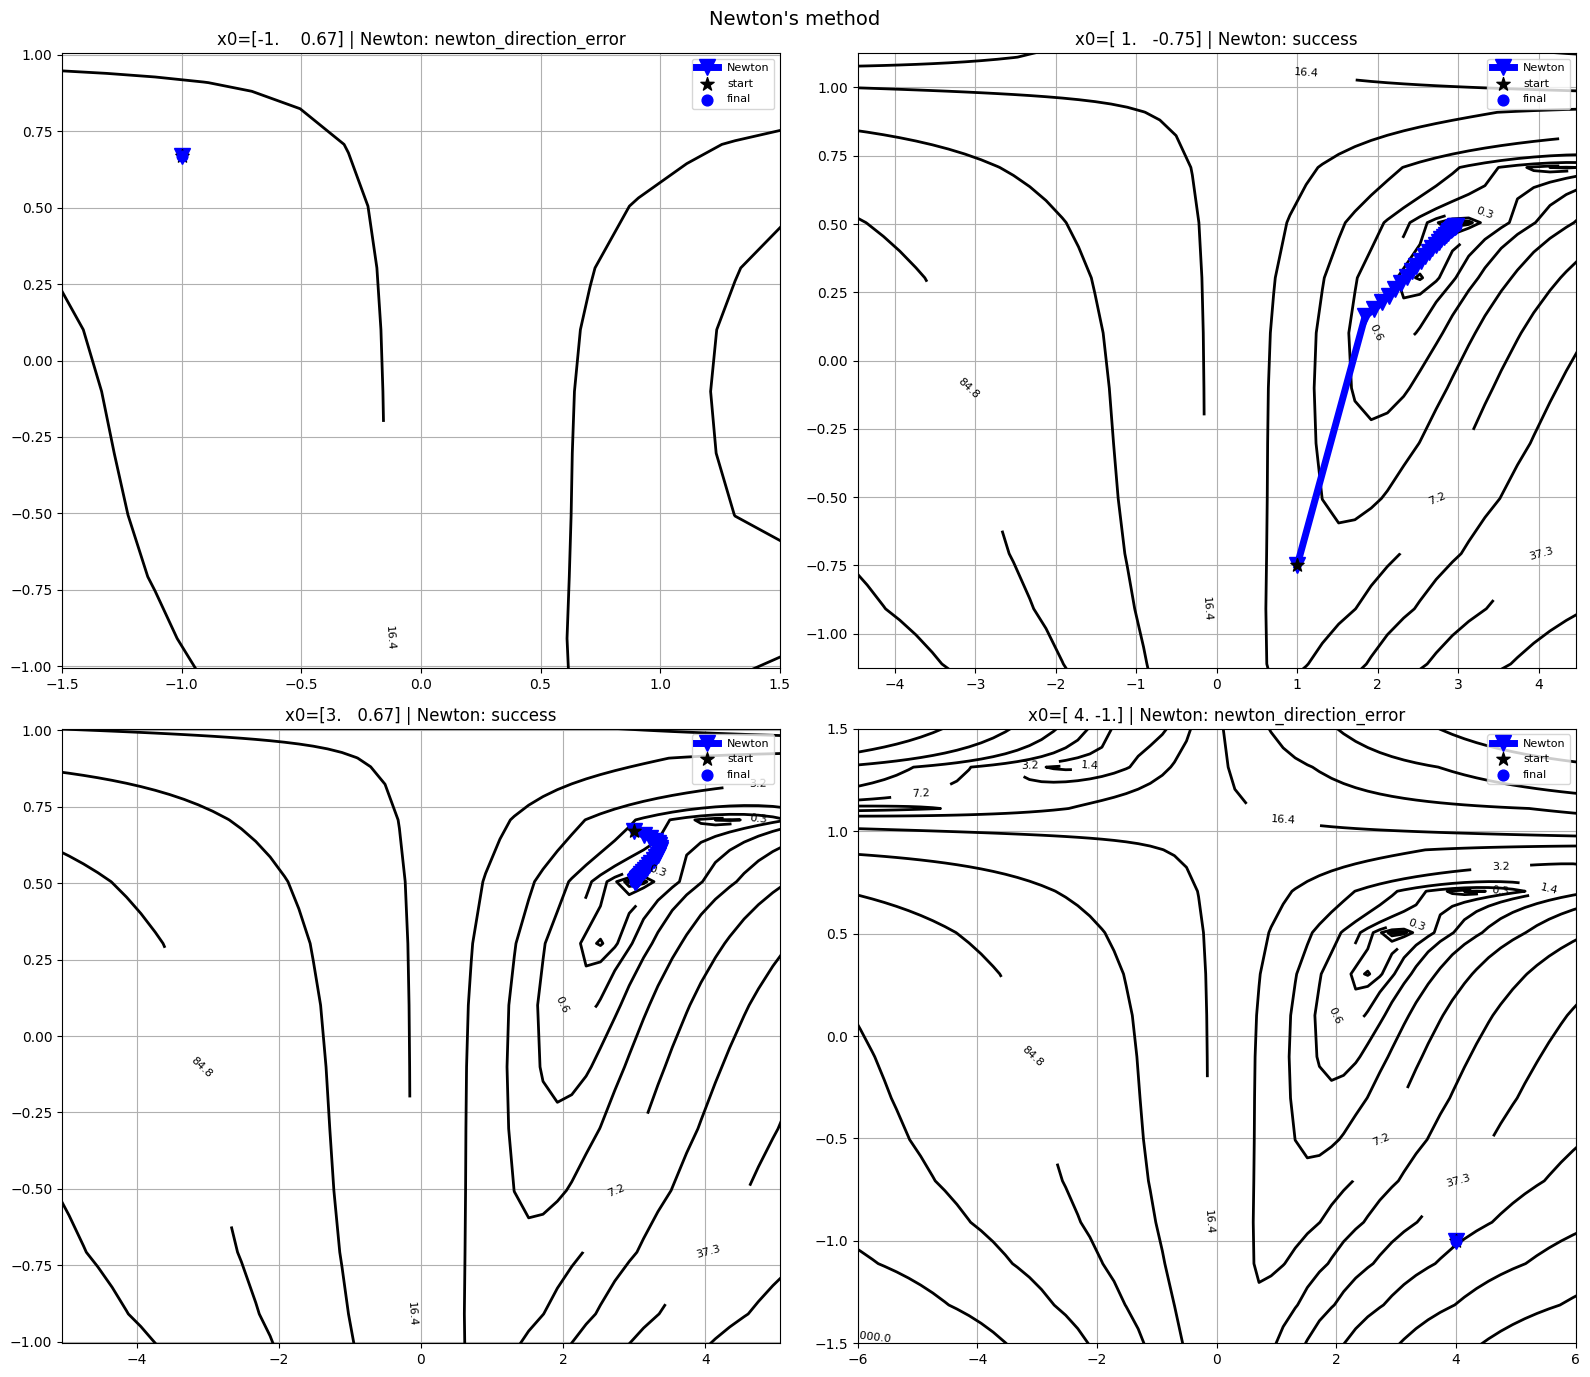

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

starts = [
    np.array([-1, 0.67]),
    np.array([1, -0.75]),
    np.array([3.0, 0.67]),
    np.array([4.0, -1.0]),
]

xrange, yrange = [-10, 10], [-10, 10]
lvls = np.geomspace(1e-2, 1e3, 15)

def draw_panel(ax, x0, hist, msg, x_end, color, method_name):
    plt.sca(ax)
    plot_levels(oracle.func, xrange=xrange, yrange=yrange, levels=lvls)
    if hist is not None and hist.get('x'):
        plot_trajectory(oracle.func, hist['x'], fit_axis=True, color=color, label=method_name)
    ax.scatter([x0[0]], [x0[1]], c='k', marker='*', s=100, zorder=5, label='старт')
    ax.scatter([x_end[0]], [x_end[1]], c=color, marker='o', s=60, zorder=5, label='конец')
    ax.set_title(f"старт={x0} | {method_name}: {msg}")
    ax.legend(loc='best', fontsize=8)
    ax.set_aspect('auto')

fig_gd, axes_gd = plt.subplots(2, 2, figsize=(16, 14))
axes_gd = axes_gd.ravel()
for ax, x0 in zip(axes_gd, starts):
    x_gd, msg_gd, hist_gd = gradient_descent(
        oracle, x0, trace=True, max_iter=5000, tolerance=1e-9,
        line_search_options={'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.9},
    )
    draw_panel(ax, x0, hist_gd, msg_gd, x_gd, 'red', 'ГС')
fig_gd.suptitle('Градиентный спуск', fontsize=14)
plt.tight_layout()
plt.show()

fig_nt, axes_nt = plt.subplots(2, 2, figsize=(16, 14))
axes_nt = axes_nt.ravel()
for ax, x0 in zip(axes_nt, starts):
    x_nt, msg_nt, hist_nt = newton(
        oracle, x0, trace=True, max_iter=200, tolerance=1e-9,
        line_search_options={'method': 'Armijo', 'alpha_0': 0.2, 'c1': 1e-4},
    )
    draw_panel(ax, x0, hist_nt, msg_nt, x_nt, 'blue', 'Ньютон')
fig_nt.suptitle('Метод Ньютона', fontsize=14)
plt.tight_layout()
plt.show()


### Карта бассейнов притяжения

In [295]:
def classify_point(x_fin, msg, oracle, r_tol=0.25):
    # -1: не сошлось / плохая численная точка (черный)
    #  0: рядом с глобальным минимумом (зеленый)
    #  1: сошлось, но не рядом (другой цвет)
    if msg != 'success' or np.any(~np.isfinite(x_fin)):
        return -1

    x_fin = np.asarray(x_fin, dtype=float).reshape(-1)
    x_global = np.array([3.0, 0.5], dtype=float)

    return 0 if np.linalg.norm(x_fin - x_global) <= r_tol else 1

In [299]:
oracle = NonConvexOracle()

N = 100
xv = np.linspace(-5, 5, N)
yv = np.linspace(-5, 5, N)

grid_gd = np.full((N, N), -1, dtype=int)
grid_nt = np.full((N, N), -1, dtype=int)

for i, x in enumerate(xv):
    for j, y in enumerate(yv):
        x0 = np.array([x, y], dtype=float)

        x_fin, msg, _ = gradient_descent(
            oracle, x0, trace=False, max_iter=1000, tolerance=1e-9,
            line_search_options={'method': 'Armijo', 'alpha_0': 1.0, 'c1': 1e-4}
        )
        grid_gd[j, i] = classify_point(x_fin, msg, oracle)

        x_fin, msg, _ = newton(
            oracle, x0, trace=False, max_iter=100, tolerance=1e-9,
            line_search_options={'method': 'Armijo', 'alpha_0': 1.0, 'c1': 1e-4}
        )
        grid_nt[j, i] = classify_point(x_fin, msg, oracle)

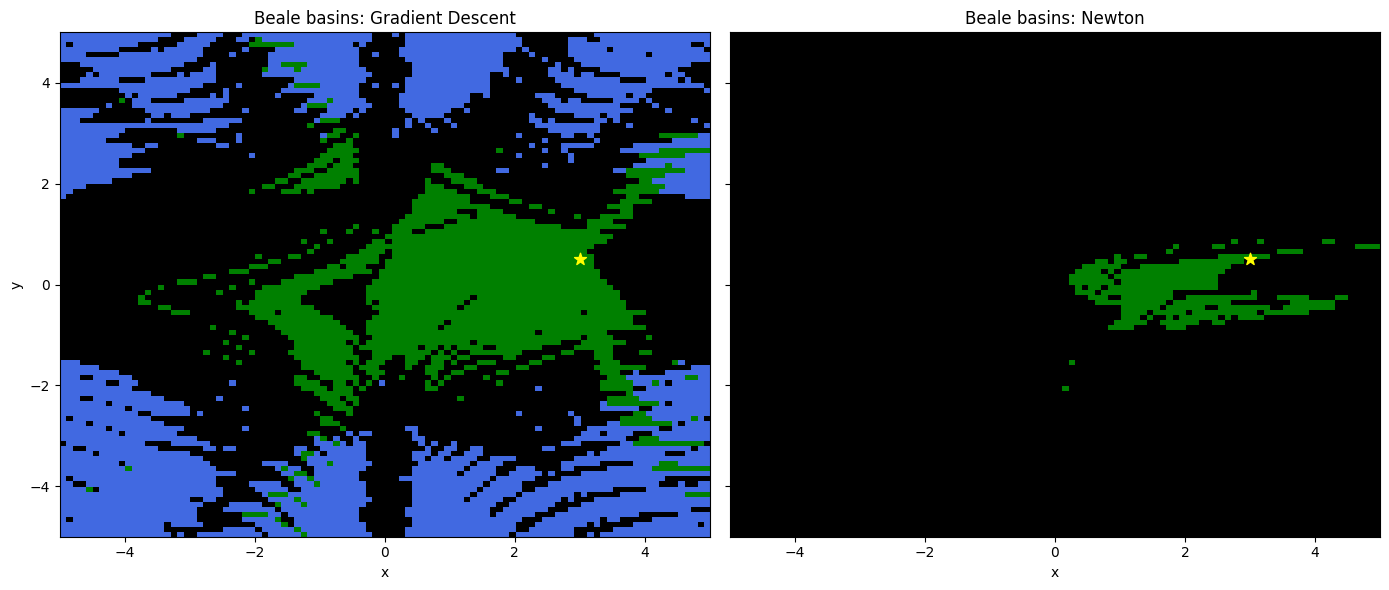

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm

cmap = ListedColormap(['black', 'green', 'royalblue', 'gray'])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].imshow(grid_gd, origin='lower', extent=[-5,5,-5,5], cmap=cmap, norm=norm, aspect='auto')
axes[0].set_title('Бассейны Била: градиентный спуск')
axes[0].set_xlabel(r'$x$'); axes[0].set_ylabel(r'$y$')

axes[1].imshow(grid_nt, origin='lower', extent=[-5,5,-5,5], cmap=cmap, norm=norm, aspect='auto')
axes[1].set_title('Бассейны Била: Ньютон')
axes[1].set_xlabel(r'$x$')

for ax in axes:
    ax.scatter([3.0], [0.5], c='yellow', s=80, marker='*')

plt.tight_layout()
plt.show()